In [1]:
# PART 1: Import Required Librarie
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import winsound
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow Version: 2.20.0
GPU Available: []


In [2]:


# PART 2: Setup Dataset Paths and Variables

img_size = 128

# Categories mapping: 0 = open_eyes, 1 = close_eyes
categories = {'open_eyes': 0, 'close_eyes': 1}

print("Dataset paths configured:")
print("- Training: ./data/train/")
print("- Testing: ./data/test/")
print("- Image size: 128x128")



Dataset paths configured:
- Training: ./data/train/
- Testing: ./data/test/
- Image size: 128x128


In [3]:
# PART 3: Setup Data Generators (Memory-Efficient)

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)

# Only rescaling for test data (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators that load images in batches
batch_size = 32

# Important: Specify class_indices to match our desired mapping
# 0 = open_eyes, 1 = close_eyes
train_generator = train_datagen.flow_from_directory(
    './data/train',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True,
    classes=['open_eyes', 'close_eyes']  # This ensures correct label mapping
)

test_generator = test_datagen.flow_from_directory(
    './data/test',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False,
    classes=['open_eyes', 'close_eyes']  # This ensures correct label mapping
)

print(f"\nTraining samples: {train_generator.samples}")
print(f"Test samples: {test_generator.samples}")
print(f"Classes: {train_generator.class_indices}")
print(f"Batch size: {batch_size}")
print("\n✓ Data generators created successfully - images will load in batches!")
print("✓ Label mapping: open_eyes=0, close_eyes=1")


Found 81675 images belonging to 2 classes.
Found 3223 images belonging to 2 classes.

Training samples: 81675
Test samples: 3223
Classes: {'open_eyes': 0, 'close_eyes': 1}
Batch size: 32

✓ Data generators created successfully - images will load in batches!
✓ Label mapping: open_eyes=0, close_eyes=1
Found 3223 images belonging to 2 classes.

Training samples: 81675
Test samples: 3223
Classes: {'open_eyes': 0, 'close_eyes': 1}
Batch size: 32

✓ Data generators created successfully - images will load in batches!
✓ Label mapping: open_eyes=0, close_eyes=1


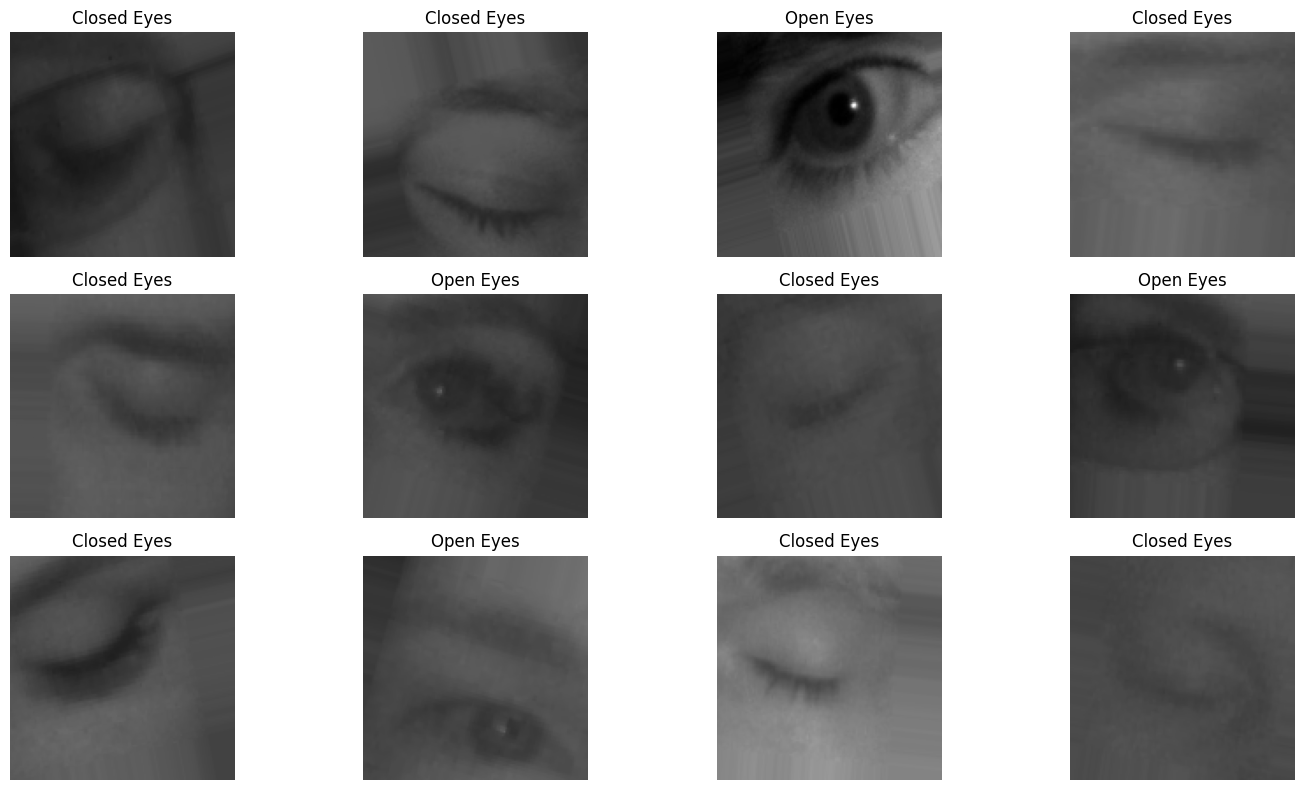

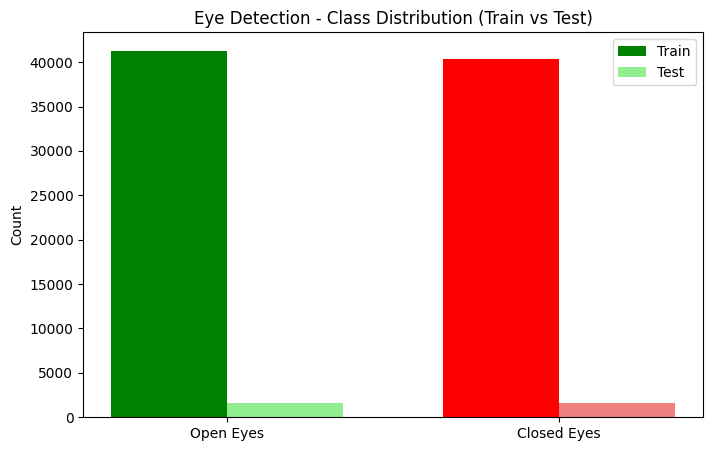

In [4]:
# PART 4: Visualize Sample Images

# Get a batch of images from the generator
sample_images, sample_labels = next(train_generator)

plt.figure(figsize=(15, 8))
for i in range(min(12, len(sample_images))):
    plt.subplot(3, 4, i+1)
    plt.imshow(sample_images[i])
    # 0 = open_eyes, 1 = close_eyes
    plt.title(f"{'Open Eyes' if sample_labels[i] == 0 else 'Closed Eyes'}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Class distribution
train_class_counts = np.bincount(train_generator.classes)
test_class_counts = np.bincount(test_generator.classes)

plt.figure(figsize=(8, 5))
x_pos = np.arange(2)
width = 0.35

plt.bar(x_pos - width/2, train_class_counts, width, label='Train', color=['green', 'red'])
plt.bar(x_pos + width/2, test_class_counts, width, label='Test', color=['lightgreen', 'lightcoral'])
plt.xticks(x_pos, ['Open Eyes', 'Closed Eyes'])
plt.title('Eye Detection - Class Distribution (Train vs Test)')
plt.ylabel('Count')
plt.legend()
plt.show()

# Reset generator
train_generator.reset()


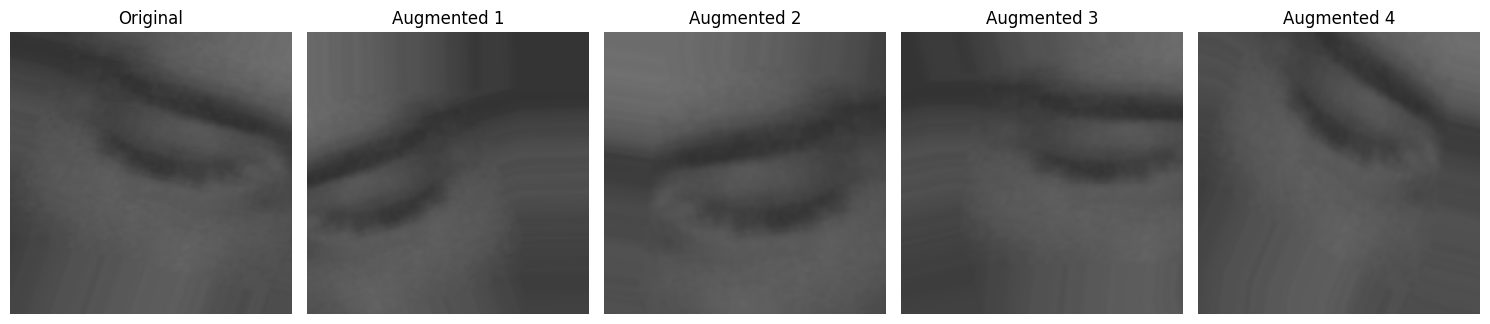

In [5]:
# PART 5: Visualize Data Augmentation

# Get one sample image
sample_img, sample_label = next(train_generator)
original_img = sample_img[0]

# Create a temporary generator for augmentation visualization
aug_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)

# Expand dimensions for the generator
sample_for_aug = np.expand_dims(original_img, axis=0)

plt.figure(figsize=(15, 5))
plt.subplot(1, 5, 1)
plt.imshow(original_img)
plt.title('Original')
plt.axis('off')

i = 2
for batch in aug_datagen.flow(sample_for_aug, batch_size=1):
    plt.subplot(1, 5, i)
    plt.imshow(batch[0])
    plt.title(f'Augmented {i-1}')
    plt.axis('off')
    i += 1
    if i > 5:
        break
plt.tight_layout()
plt.show()

# Reset generator
train_generator.reset()


In [6]:
# PART 6: Build CNN Model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),
    
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),
    
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),
    
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),
    
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 5,244,097 (20.00 MB)

 Trainable params: 5,241,601 (20.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [7]:

# PART 7: Define Callbacks

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]


In [8]:
# PART 8: Train the Model

epochs = 50

# Calculate steps per epoch
steps_per_epoch = train_generator.samples // batch_size
validation_steps = test_generator.samples // batch_size

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=test_generator,
    validation_steps=validation_steps,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
2552/2552 ━━━━━━━━━━━━━━━━━━━━ 3465s 1s/step - accuracy: 0.8802 - loss: 0.2822 - val_accuracy: 0.4825 - val_loss: 0.9056 - learning_rate: 0.0010
Epoch 2/50
2552/2552 ━━━━━━━━━━━━━━━━━━━━ 3465s 1s/step - accuracy: 0.8802 - loss: 0.2822 - val_accuracy: 0.4825 - val_loss: 0.9056 - learning_rate: 0.0010
Epoch 2/50
2552/2552 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9688 - loss: 0.0671 - val_accuracy: 0.4800 - val_loss: 0.9670 - learning_rate: 0.0010
Epoch 3/50
2552/2552 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9688 - loss: 0.0671 - val_accuracy: 0.4800 - val_loss: 0.9670 - learning_rate: 0.0010
Epoch 3/50
2552/2552 ━━━━━━━━━━━━━━━━━━━━ 1947s 763ms/step - accuracy: 0.9526 - loss: 0.1282 - val_accuracy: 0.8487 - val_loss: 0.4331 - learning_rate: 0.0010
Epoch 4/50
2552/2552 ━━━━━━━━━━━━━━━━━━━━ 1947s 763ms/step - accuracy: 0.9526 - loss: 0.1282 - val_accuracy: 0.8487 - val_loss: 0.4331 - learning_rate: 0.0010
Epoch 4/50
2552/2552 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - acc

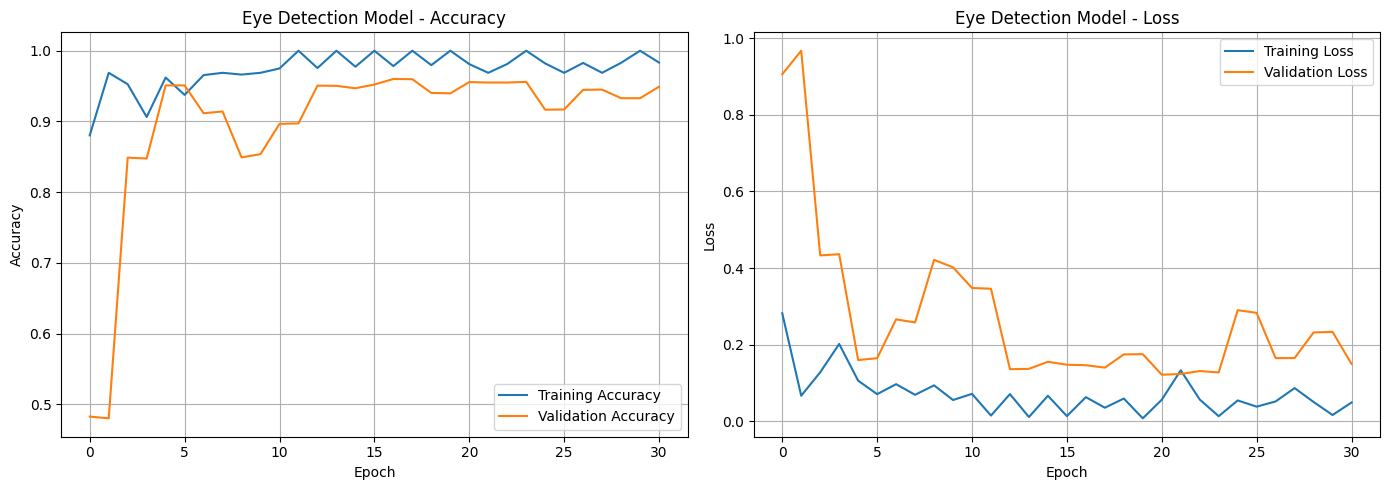

In [9]:

# PART 9: Plot Training History

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Eye Detection Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Eye Detection Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


101/101 ━━━━━━━━━━━━━━━━━━━━ 15s 141ms/step
101/101 ━━━━━━━━━━━━━━━━━━━━ 15s 141ms/step
Classification Report:
              precision    recall  f1-score   support

   Open Eyes       1.00      0.92      0.96      1657
 Closed Eyes       0.92      1.00      0.96      1566

    accuracy                           0.96      3223
   macro avg       0.96      0.96      0.96      3223
weighted avg       0.96      0.96      0.96      3223

Classification Report:
              precision    recall  f1-score   support

   Open Eyes       1.00      0.92      0.96      1657
 Closed Eyes       0.92      1.00      0.96      1566

    accuracy                           0.96      3223
   macro avg       0.96      0.96      0.96      3223
weighted avg       0.96      0.96      0.96      3223



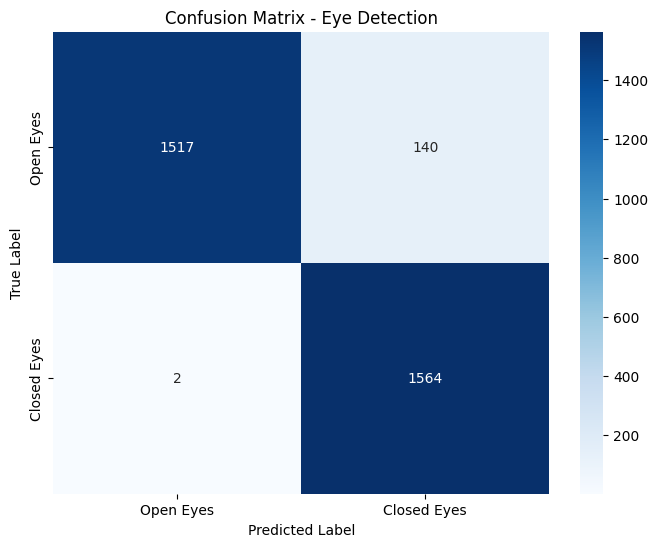


Test Accuracy: 95.56%
Test Loss: 0.1219


In [10]:
# PART 10: Evaluate the Model

# Reset test generator
test_generator.reset()

# Predict on test data
y_pred = model.predict(test_generator, steps=validation_steps + 1, verbose=1)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()

# Get true labels
y_test = test_generator.classes[:len(y_pred_classes)]

print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=['Open Eyes', 'Closed Eyes']))

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Open Eyes', 'Closed Eyes'],
            yticklabels=['Open Eyes', 'Closed Eyes'])
plt.title('Confusion Matrix - Eye Detection')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

test_generator.reset()
test_loss, test_accuracy = model.evaluate(test_generator, steps=validation_steps, verbose=0)
print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


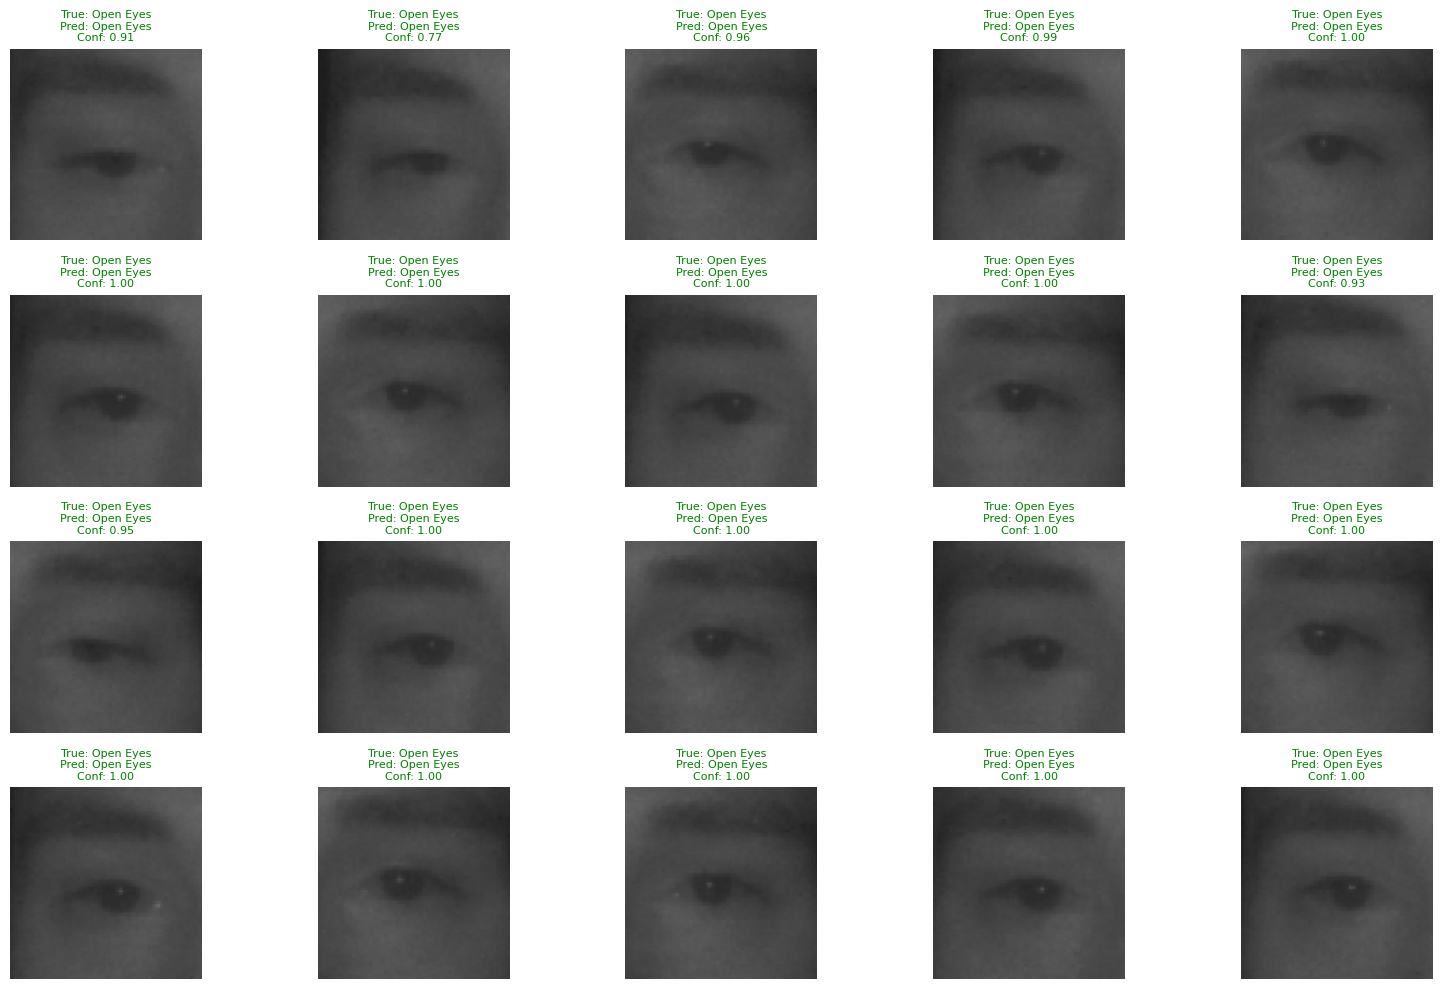

In [11]:
# PART 11: Visualize Predictions on Test Set

# Reset and get test images
test_generator.reset()
test_images, test_labels = next(test_generator)

# Make predictions on this batch
predictions = model.predict(test_images, verbose=0)
pred_classes = (predictions > 0.5).astype(int).flatten()

plt.figure(figsize=(16, 10))
for i in range(min(20, len(test_images))):
    plt.subplot(4, 5, i+1)
    plt.imshow(test_images[i])
    
    # 0 = open_eyes, 1 = close_eyes
    true_label = 'Open Eyes' if test_labels[i] == 0 else 'Closed Eyes'
    pred_label = 'Open Eyes' if pred_classes[i] == 0 else 'Closed Eyes'
    confidence = predictions[i][0] if pred_classes[i] == 1 else 1 - predictions[i][0]
    
    color = 'green' if test_labels[i] == pred_classes[i] else 'red'
    plt.title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}', 
              color=color, fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Reset generator
test_generator.reset()


In [13]:
# PART 12: Save the Model

# Save in Keras format (recommended)
model.save('eye_detector_model.keras')
print("✓ Model saved as 'eye_detector_model.keras'")

# Optional: Save in HDF5 format (legacy)
try:
    model.save('eye_detector_model.h5')
    print("✓ Model saved as 'eye_detector_model.h5'")
except:
    print("Note: H5 format may require h5py package")

print("\nTo load the model later, use:")
print("model = keras.models.load_model('eye_detector_model.keras')")


✓ Model saved as 'eye_detector_model.keras'
✓ Model saved as 'eye_detector_model.h5'

To load the model later, use:
model = keras.models.load_model('eye_detector_model.keras')
✓ Model saved as 'eye_detector_model.h5'

To load the model later, use:
model = keras.models.load_model('eye_detector_model.keras')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step


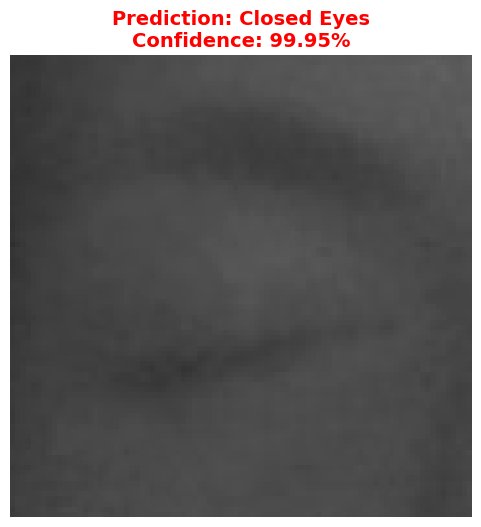

Result: Closed Eyes with 99.95% confidence


In [14]:
# PART 13: Test on a Single New Image

def predict_eye_state(image_path, model):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (img_size, img_size))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)
    
    prediction = model.predict(img_input)[0][0]
    
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    
    # prediction > 0.5 means close_eyes (label 1)
    # prediction < 0.5 means open_eyes (label 0)
    if prediction > 0.5:
        label = 'Closed Eyes'
        confidence = prediction * 100
        color = 'red'
    else:
        label = 'Open Eyes'
        confidence = (1 - prediction) * 100
        color = 'green'
    
    plt.title(f'Prediction: {label}\nConfidence: {confidence:.2f}%', 
              color=color, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()
    
    return label, confidence

test_image_path = 'data\\test\\close_eyes\\s0002_00011_0_0_0_0_0_01.png'
result, conf = predict_eye_state(test_image_path, model)
print(f"Result: {result} with {conf:.2f}% confidence")


In [ ]:
# PART 14: Real-time Webcam Eye Detection (Fixed - Uses Face Regions)

def detect_eyes_webcam(model, confidence_threshold=0.5, beep_duration=500):
    """
    Fixed approach: Uses face detection to locate eye regions.
    Press 'i' to toggle between normal/inverted prediction logic if not working correctly.
    """
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    
    cap = cv2.VideoCapture(0)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
    
    print("Starting eye detection webcam...")
    print("Using face-based eye region detection")
    print("Press 'q' to quit, 'i' to invert logic\n")
    
    beep_cooldown = 0
    closed_frame_count = 0
    invert_logic = False  # Start with normal logic
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Check for key presses
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord('i'):
            invert_logic = not invert_logic
            print(f"Logic inverted: {invert_logic}")
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.3, 5, minSize=(120, 120))
        
        eyes_closed = False
        detected_count = 0
        all_predictions = []
        
        for (fx, fy, fw, fh) in faces:
            # Draw face box
            cv2.rectangle(frame, (fx, fy), (fx+fw, fy+fh), (255, 255, 0), 1)
            
            # Define left and right eye regions based on face geometry
            eye_width = int(fw * 0.25)
            eye_height = int(fh * 0.15)
            
            # Left eye region
            left_eye_x = fx + int(fw * 0.20)
            left_eye_y = fy + int(fh * 0.30)
            
            # Right eye region  
            right_eye_x = fx + int(fw * 0.55)
            right_eye_y = fy + int(fh * 0.30)
            
            eye_regions = [
                ('Left', left_eye_x, left_eye_y, eye_width, eye_height),
                ('Right', right_eye_x, right_eye_y, eye_width, eye_height)
            ]
            
            for (eye_name, ex, ey, ew, eh) in eye_regions:
                # Extract eye region from color frame
                eye_roi = frame[ey:ey+eh, ex:ex+ew]
                
                if eye_roi.size == 0 or eye_roi.shape[0] < 10 or eye_roi.shape[1] < 10:
                    continue
                
                try:
                    # Convert to RGB
                    eye_roi_rgb = cv2.cvtColor(eye_roi, cv2.COLOR_BGR2RGB)
                    
                    # Resize and normalize
                    eye_resized = cv2.resize(eye_roi_rgb, (img_size, img_size))
                    eye_normalized = eye_resized / 255.0
                    eye_input = np.expand_dims(eye_normalized, axis=0)
                    
                    # Predict
                    prediction = model.predict(eye_input, verbose=0)[0][0]
                    all_predictions.append(prediction)
                    
                    # Determine if eye is closed based on current logic
                    if invert_logic:
                        # Inverted: lower values = closed
                        is_closed = prediction < confidence_threshold
                    else:
                        # Normal: higher values = closed
                        is_closed = prediction > confidence_threshold
                    
                    if is_closed:
                        label = 'CLOSED'
                        color = (0, 0, 255)  # Red
                        eyes_closed = True
                    else:
                        label = 'OPEN'
                        color = (0, 255, 0)  # Green
                    
                    detected_count += 1
                    
                    # Draw rectangle around eye region
                    cv2.rectangle(frame, (ex, ey), (ex+ew, ey+eh), color, 3)
                    
                    # Show label above eye
                    cv2.putText(frame, f'{eye_name}: {label}', 
                               (ex, ey-10), cv2.FONT_HERSHEY_SIMPLEX, 
                               0.5, color, 2)
                    
                    # Show prediction value below eye
                    cv2.putText(frame, f'{prediction:.2f}', 
                               (ex, ey+eh+15), cv2.FONT_HERSHEY_SIMPLEX, 
                               0.4, (255, 255, 0), 1)
                    
                except Exception as e:
                    print(f"Error processing {eye_name} eye: {e}")
                    continue
        
        # Beep if eyes are closed
        if eyes_closed:
            closed_frame_count += 1
            if closed_frame_count >= 3 and beep_cooldown <= 0:
                try:
                    winsound.Beep(1000, beep_duration)
                except:
                    pass
                beep_cooldown = 15
        else:
            closed_frame_count = 0
            beep_cooldown = max(0, beep_cooldown - 1)
        
        # Display status
        status = "⚠️ EYES CLOSED!" if eyes_closed else "✅ Eyes Open"
        status_color = (0, 0, 255) if eyes_closed else (0, 255, 0)
        
        # Background rectangle for better visibility
        cv2.rectangle(frame, (5, 5), (450, 165), (0, 0, 0), -1)
        
        cv2.putText(frame, status, (15, 45), cv2.FONT_HERSHEY_SIMPLEX, 
                   1.0, status_color, 3)
        
        cv2.putText(frame, f'Eyes detected: {detected_count}', (15, 80), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
        
        if all_predictions:
            avg_pred = sum(all_predictions) / len(all_predictions)
            if invert_logic:
                cv2.putText(frame, f'Avg: {avg_pred:.3f} (<{confidence_threshold}=closed)', 
                           (15, 105), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
            else:
                cv2.putText(frame, f'Avg: {avg_pred:.3f} (>{confidence_threshold}=closed)', 
                           (15, 105), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
        
        cv2.putText(frame, f'Inverted: {invert_logic}', (15, 130), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
        cv2.putText(frame, "Press 'I' to toggle, 'Q' to quit", (15, 155), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        
        cv2.imshow('Eye Detection - Face Region Method', frame)
    
    cap.release()
    cv2.destroyAllWindows()
    print("Eye detection stopped")
    print(f"\nFinal setting - Inverted logic: {invert_logic}")

# Start with normal logic - press 'i' to toggle if needed
detect_eyes_webcam(model, confidence_threshold=0.5)


Starting eye detection webcam...
Using face-based eye region detection
⚠️  Model predictions are INVERTED (lower = closed)
Press 'q' to quit

Eye detection stopped
Eye detection stopped


In [ ]:
# PART 15: Advanced Eye Detection with Statistics (Improved)

def detect_eyes_advanced(model, duration_seconds=30, confidence_threshold=0.5):
    eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    
    cap = cv2.VideoCapture(0)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
    
    print(f"Advanced Eye Detection - Recording for {duration_seconds} seconds...")
    print("Press 'q' to stop early\n")
    
    import time
    start_time = time.time()
    
    eye_open_count = 0
    eye_closed_count = 0
    total_detections = 0
    beep_cooldown = 0
    closed_frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        elapsed = time.time() - start_time
        if elapsed > duration_seconds:
            break
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.3, 5, minSize=(80, 80))
        
        eyes_closed = False
        
        for (fx, fy, fw, fh) in faces:
            # Define eye region (upper 65% of face only)
            eye_region_y_start = fy + int(fh * 0.1)
            eye_region_y_end = fy + int(fh * 0.65)
            
            roi_gray = gray[eye_region_y_start:eye_region_y_end, fx:fx+fw]
            roi_color = frame[eye_region_y_start:eye_region_y_end, fx:fx+fw]
            
            # Detect eyes with balanced parameters
            eyes = eye_cascade.detectMultiScale(
                roi_gray,
                scaleFactor=1.1,
                minNeighbors=5,
                minSize=(25, 25),
                maxSize=(100, 100)
            )
            
            # Filter by aspect ratio
            valid_eyes = []
            for (ex, ey, ew, eh) in eyes:
                aspect_ratio = ew / eh
                if 0.7 < aspect_ratio < 2.5:
                    valid_eyes.append((ex, ey, ew, eh))
            
            # Sort and take up to 2 eyes
            valid_eyes.sort(key=lambda e: e[0])
            
            for (ex, ey, ew, eh) in valid_eyes[:2]:
                actual_y = eye_region_y_start + ey
                actual_x = fx + ex
                
                eye_roi = roi_color[ey:ey+eh, ex:ex+ew]
                
                if eye_roi.size == 0:
                    continue
                
                eye_roi_rgb = cv2.cvtColor(eye_roi, cv2.COLOR_BGR2RGB)
                
                try:
                    eye_resized = cv2.resize(eye_roi_rgb, (img_size, img_size))
                    eye_normalized = eye_resized / 255.0
                    eye_input = np.expand_dims(eye_normalized, axis=0)
                    
                    prediction = model.predict(eye_input, verbose=0)[0][0]
                    
                    # prediction > 0.5 means close_eyes (label 1)
                    # prediction < 0.5 means open_eyes (label 0)
                    if prediction > confidence_threshold:
                        label = 'CLOSED'
                        color = (0, 0, 255)
                        eye_closed_count += 1
                        eyes_closed = True
                    else:
                        label = 'OPEN'
                        color = (0, 255, 0)
                        eye_open_count += 1
                    
                    total_detections += 1
                    
                    cv2.rectangle(frame, (actual_x, actual_y), (actual_x+ew, actual_y+eh), color, 2)
                    cv2.putText(frame, label, (actual_x, actual_y-5), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 2)
                except Exception as e:
                    continue
        
        # Beep if eyes consistently closed
        if eyes_closed:
            closed_frame_count += 1
            if closed_frame_count >= 2 and beep_cooldown <= 0:
                try:
                    winsound.Beep(1000, 300)
                except:
                    pass
                beep_cooldown = 15
        else:
            closed_frame_count = 0
        
        beep_cooldown = max(0, beep_cooldown - 1)
        
        # Display info
        info_text = [
            f'Time: {elapsed:.1f}s / {duration_seconds}s',
            f'Open: {eye_open_count} | Closed: {eye_closed_count}',
            f'Total: {total_detections}',
            'Press Q to stop'
        ]
        
        y_offset = 25
        for text in info_text:
            cv2.putText(frame, text, (10, y_offset), cv2.FONT_HERSHEY_SIMPLEX, 
                       0.5, (255, 255, 255), 1)
            y_offset += 25
        
        cv2.imshow('Advanced Eye Detection', frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()
    
    print("\n" + "="*50)
    print("EYE DETECTION SESSION REPORT")
    print("="*50)
    print(f"Duration: {elapsed:.1f} seconds")
    print(f"Total Eye Detections: {total_detections}")
    print(f"Eyes Open Count: {eye_open_count}")
    print(f"Eyes Closed Count: {eye_closed_count}")
    
    if total_detections > 0:
        open_percentage = (eye_open_count / total_detections) * 100
        closed_percentage = (eye_closed_count / total_detections) * 100
        print(f"\nEyes Open: {open_percentage:.2f}%")
        print(f"Eyes Closed: {closed_percentage:.2f}%")
    
    print("="*50)

# detect_eyes_advanced(model, duration_seconds=30)
